In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### 1. As the "Age" column has 177 NaN Values, so this column is replaced by the mean of this column.
### 2. The "Cabin" column has 687 NaN values out of 891 values. So this column will be dropped.

# Data Cleaning

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
df.drop(['PassengerId','Name','Pclass','Ticket','Cabin'],axis = 1, inplace = True)

In [8]:
df

,Survived,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,1,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,0,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...
886,0,male,27.0,0,0,13.0000,S
887,1,female,19.0,0,0,30.0000,S
888,0,female,NaN,1,2,23.4500,S
889,1,male,26.0,0,0,30.0000,C


In [9]:
age_mean = df.Age.mean()
age_mean

29.69911764705882

In [10]:
df['Age'] = df['Age'].fillna(age_mean) # Replacing the NaN values of "Age" columns with its mean value

In [11]:
df

,Survived,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,male,22.000000,1,0,7.2500,S
1,1,female,38.000000,1,0,71.2833,C
2,1,female,26.000000,0,0,7.9250,S
3,1,female,35.000000,1,0,53.1000,S
4,0,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...
886,0,male,27.000000,0,0,13.0000,S
887,1,female,19.000000,0,0,30.0000,S
888,0,female,29.699118,1,2,23.4500,S
889,1,male,26.000000,0,0,30.0000,C


In [12]:
df.isna().sum()

Survived    0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64

In [13]:
df.Sex.value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

# Visualization

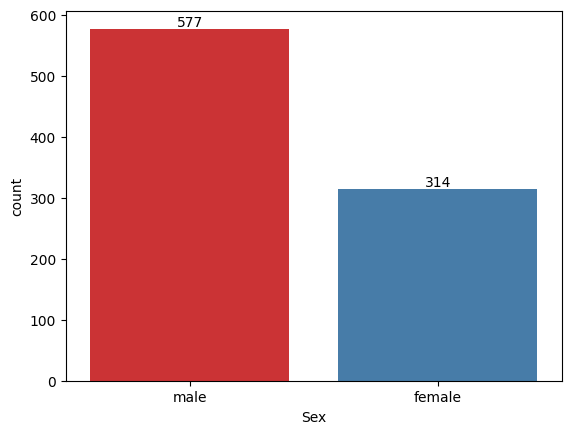

In [14]:
ax = sns.countplot(x = df['Sex'],data = df,palette = 'Set1')
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2,height),
        va = 'bottom',
        ha = 'center'
    )
plt.show()

In [15]:
sns.countplot

<function seaborn.categorical.countplot(data=None, *, x=None, y=None, hue=None, order=None, hue_order=None, orient=None, color=None, palette=None, saturation=0.75, fill=True, hue_norm=None, stat='count', width=0.8, dodge='auto', gap=0, log_scale=None, native_scale=False, formatter=None, legend='auto', ax=None, **kwargs)>

In [16]:
df.Survived.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

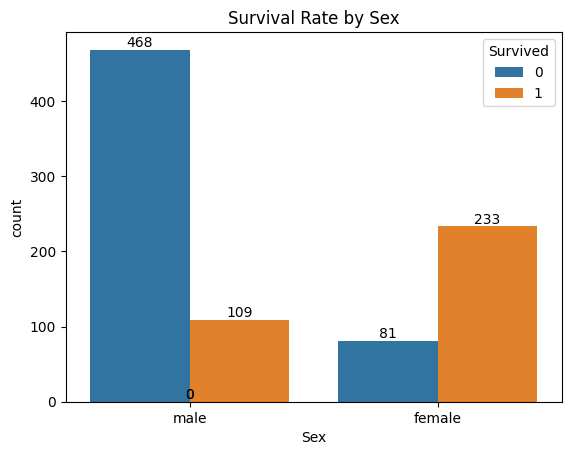

In [17]:
# Survived = 0 (did not survive)

# Survived = 1 (survived)

ax = sns.countplot(x = 'Sex',hue = 'Survived', data = df)
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        ha = 'center',
        va = 'bottom'
    )
plt.title("Survival Rate by Sex")
plt.show()

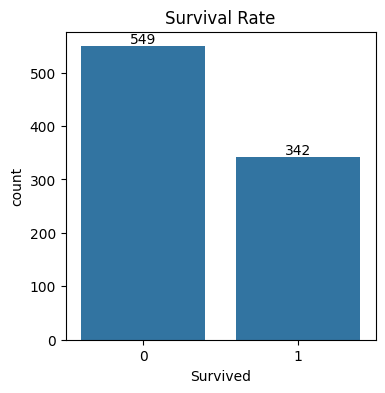

In [18]:
#ax = sns.barplot(x=df.Sex,y = df.Survived, data=df)
plt.figure(figsize=(4,4))
ax = sns.countplot(x = df.Survived)
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        ha = 'center',
        va = 'bottom'
    )
plt.title("Survival Rate")
plt.show()

Sex
female    233
male      109
Name: Survived, dtype: int64


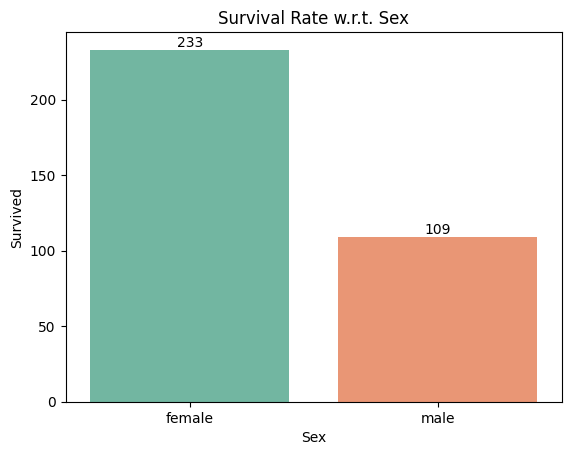

In [19]:
sex_survived = df.groupby('Sex')['Survived'].sum()
print(sex_survived)
ax = sns.barplot(x = sex_survived.index, y = sex_survived, palette = "Set2")
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        ha = 'center',
        va= 'bottom'
    )
plt.title('Survival Rate w.r.t. Sex')
plt.show()

0 -> Didn't Survive
1-> Survived


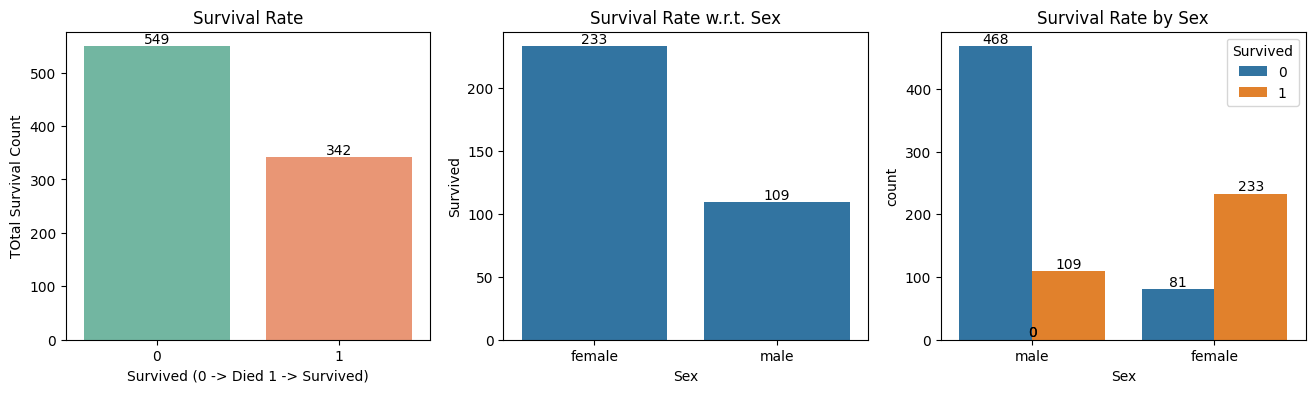

In [20]:
print("0 -> Didn't Survive\n1-> Survived")
plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
ax = sns.countplot(x = df.Survived, palette = "Set2")
#ax = sns.countplot(x='Survived', hue='Sex',data=df,palette='Set2')
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        ha = 'center',
        va = 'bottom'
    )
plt.xlabel('Survived (0 -> Died 1 -> Survived)')
plt.ylabel('TOtal Survival Count')
plt.title("Survival Rate")

plt.subplot(1,3,2)
sex_survived = df.groupby('Sex')['Survived'].sum()
#print(sex_survived)
colors = ['Red', 'Green']
ax = sns.barplot(x = sex_survived.index, y = sex_survived)
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        ha = 'center',
        va= 'bottom'
    )
plt.title('Survival Rate w.r.t. Sex')

plt.subplot(1,3,3)
ax = sns.countplot(x = 'Sex',hue = 'Survived', data = df)
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        ha = 'center',
        va = 'bottom'
    )

plt.title("Survival Rate by Sex")
plt.show()

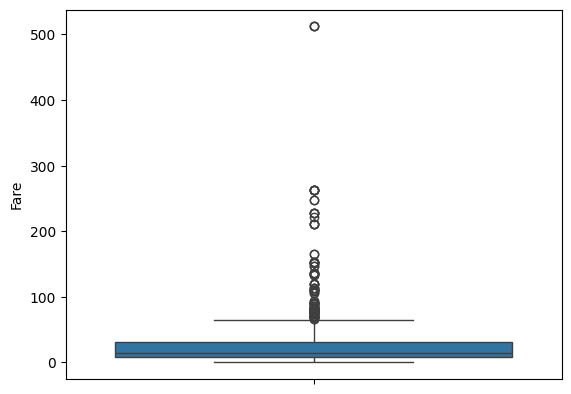

In [21]:
sns.boxplot(y = df.Fare)
plt.show()

In [22]:
df

,Survived,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,male,22.000000,1,0,7.2500,S
1,1,female,38.000000,1,0,71.2833,C
2,1,female,26.000000,0,0,7.9250,S
3,1,female,35.000000,1,0,53.1000,S
4,0,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...
886,0,male,27.000000,0,0,13.0000,S
887,1,female,19.000000,0,0,30.0000,S
888,0,female,29.699118,1,2,23.4500,S
889,1,male,26.000000,0,0,30.0000,C


In [23]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

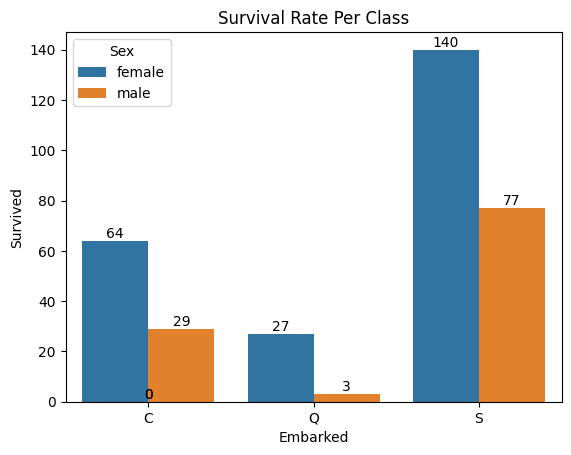

In [24]:
embarked_sex_survived = (
    df.groupby(['Embarked','Sex'])['Survived'].sum().reset_index()
)

ax = sns.barplot(x='Embarked',
                 y='Survived',
                 hue='Sex',
                 data=embarked_sex_survived)

for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                (bar.get_x() + bar.get_width()/2, height),
                ha='center',
                va='bottom')
plt.title('Survival Rate Per Class')
plt.show()

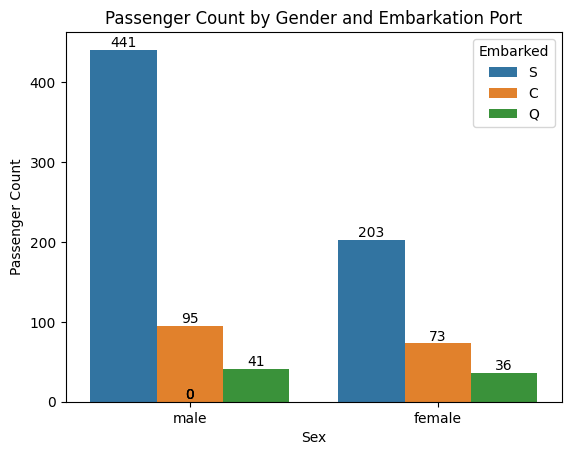

In [25]:
ax = sns.countplot(x='Sex',
                   hue='Embarked',
                   data=df)

for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        ha='center',
        va='bottom'
    )

plt.title("Passenger Count by Gender and Embarkation Port")
plt.xlabel("Sex")
plt.ylabel("Passenger Count")
plt.show()

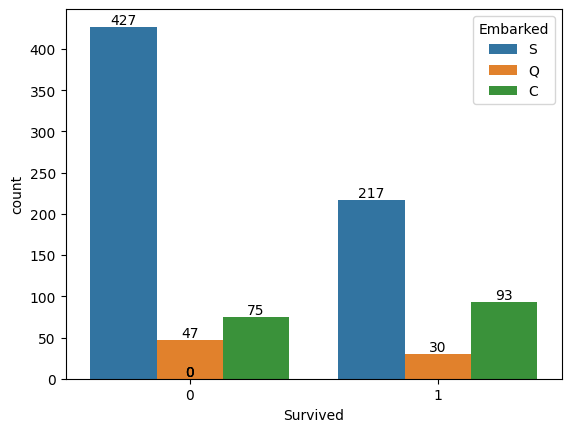

In [26]:
ax = sns.countplot(x = df.Survived, hue = df.Embarked)
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        ha = 'center',
        va = 'bottom'
    )
plt.show()

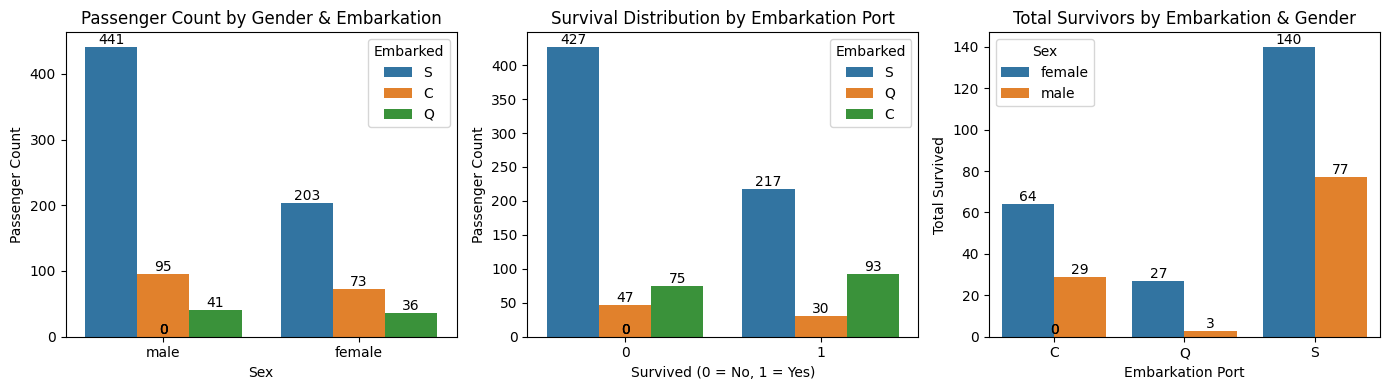

In [27]:
plt.figure(figsize=(14,4))

# ------------------ Subplot 1 ------------------
plt.subplot(1,3,1)
ax = sns.countplot(x='Sex',
                   hue='Embarked',
                   data=df)

for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                (bar.get_x() + bar.get_width()/2, height),
                ha='center',
                va='bottom')

plt.title("Passenger Count by Gender & Embarkation")
plt.xlabel("Sex")
plt.ylabel("Passenger Count")


# ------------------ Subplot 2 ------------------
plt.subplot(1,3,2)
ax = sns.countplot(x='Survived',
                   hue='Embarked',
                   data=df)

for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                (bar.get_x() + bar.get_width()/2, height),
                ha='center',
                va='bottom')

plt.title("Survival Distribution by Embarkation Port")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Passenger Count")


# ------------------ Subplot 3 ------------------
plt.subplot(1,3,3)

embarked_sex_survived = (
    df.groupby(['Embarked','Sex'])['Survived']
      .sum()
      .reset_index()
)

ax = sns.barplot(x='Embarked',
                 y='Survived',
                 hue='Sex',
                 data=embarked_sex_survived)

for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                (bar.get_x() + bar.get_width()/2, height),
                ha='center',
                va='bottom')

plt.title("Total Survivors by Embarkation & Gender")
plt.xlabel("Embarkation Port")
plt.ylabel("Total Survived")

plt.tight_layout()
plt.show()

In [28]:
df

,Survived,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,male,22.000000,1,0,7.2500,S
1,1,female,38.000000,1,0,71.2833,C
2,1,female,26.000000,0,0,7.9250,S
3,1,female,35.000000,1,0,53.1000,S
4,0,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...
886,0,male,27.000000,0,0,13.0000,S
887,1,female,19.000000,0,0,30.0000,S
888,0,female,29.699118,1,2,23.4500,S
889,1,male,26.000000,0,0,30.0000,C


In [29]:
df.Embarked.value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [30]:
uni = df['Embarked'].unique()
uni

array(['S', 'C', 'Q', nan], dtype=object)

In [31]:
df


,Survived,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,male,22.000000,1,0,7.2500,S
1,1,female,38.000000,1,0,71.2833,C
2,1,female,26.000000,0,0,7.9250,S
3,1,female,35.000000,1,0,53.1000,S
4,0,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...
886,0,male,27.000000,0,0,13.0000,S
887,1,female,19.000000,0,0,30.0000,S
888,0,female,29.699118,1,2,23.4500,S
889,1,male,26.000000,0,0,30.0000,C


# Encoding

In [32]:
from sklearn.preprocessing import LabelEncoder

In [33]:
le = LabelEncoder()

In [34]:
from pandas.api.types import is_numeric_dtype

In [35]:
for col in df.columns:
    if is_numeric_dtype(df[col]):
        continue
    else:
        df[col] = le.fit_transform(df[col])
df

,Survived,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,1,22.000000,1,0,7.2500,2
1,1,0,38.000000,1,0,71.2833,0
2,1,0,26.000000,0,0,7.9250,2
3,1,0,35.000000,1,0,53.1000,2
4,0,1,35.000000,0,0,8.0500,2
...,...,...,...,...,...,...,...
886,0,1,27.000000,0,0,13.0000,2
887,1,0,19.000000,0,0,30.0000,2
888,0,0,29.699118,1,2,23.4500,2
889,1,1,26.000000,0,0,30.0000,0


In [36]:
# Handling Outliers for "Fare" column
import numpy as np
df['Fare'] = np.log1p(df['Fare'])

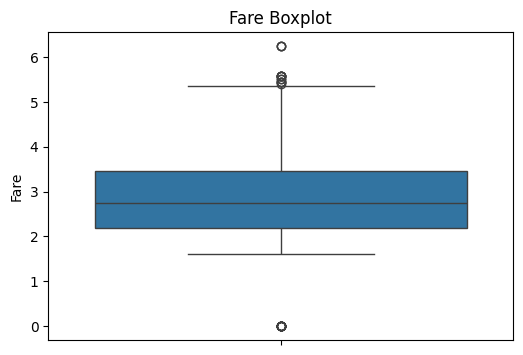

In [37]:


plt.figure(figsize=(6,4))
sns.boxplot(y=df['Fare'])
plt.title("Fare Boxplot")
plt.show()

In [38]:
df

,Survived,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,1,22.000000,1,0,2.110213,2
1,1,0,38.000000,1,0,4.280593,0
2,1,0,26.000000,0,0,2.188856,2
3,1,0,35.000000,1,0,3.990834,2
4,0,1,35.000000,0,0,2.202765,2
...,...,...,...,...,...,...,...
886,0,1,27.000000,0,0,2.639057,2
887,1,0,19.000000,0,0,3.433987,2
888,0,0,29.699118,1,2,3.196630,2
889,1,1,26.000000,0,0,3.433987,0


In [39]:
x = df.drop('Survived',axis = 1)
y = df[['Survived']]

In [40]:
x

,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,22.000000,1,0,2.110213,2
1,0,38.000000,1,0,4.280593,0
2,0,26.000000,0,0,2.188856,2
3,0,35.000000,1,0,3.990834,2
4,1,35.000000,0,0,2.202765,2
...,...,...,...,...,...,...
886,1,27.000000,0,0,2.639057,2
887,0,19.000000,0,0,3.433987,2
888,0,29.699118,1,2,3.196630,2
889,1,26.000000,0,0,3.433987,0


In [41]:
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [42]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size = .2, random_state = 42)

In [43]:
from sklearn.neighbors import KNeighborsClassifier
knn_cf = KNeighborsClassifier(n_neighbors = 5)
knn_cf.fit(xtrain,ytrain)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [44]:
print('Train accuracy: ',knn_cf.score(xtrain, ytrain))
print('Test Accuracy: ',knn_cf.score(xtrain,ytrain))

Train accuracy:  0.8230337078651685
Test Accuracy:  0.8230337078651685


In [45]:
y_pred = knn_cf.predict(xtest)
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1], dtype=int64)

In [46]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

In [47]:
print('Accuracy score: ',accuracy_score(y_pred, ytest))

Accuracy score:  0.7318435754189944


In [48]:
print('Classification Report: \n',classification_report(ytest,y_pred))

Classification Report: 
               precision    recall  f1-score   support

           0       0.73      0.86      0.79       105
           1       0.73      0.55      0.63        74

    accuracy                           0.73       179
   macro avg       0.73      0.71      0.71       179
weighted avg       0.73      0.73      0.72       179



In [49]:
cm = confusion_matrix(y_pred, ytest)

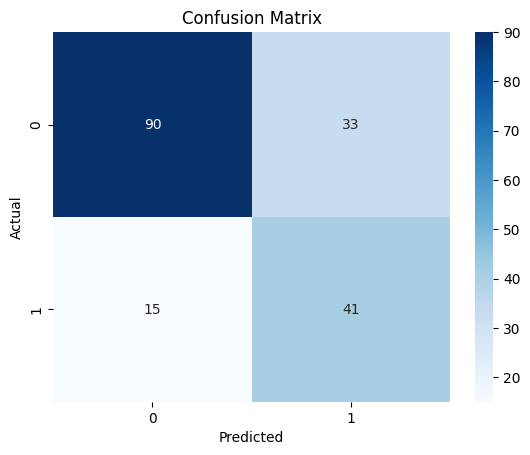

In [50]:
sns.heatmap(cm, 
            annot=True,      # show numbers inside cells
            fmt='d',         # integer format
            cmap='Blues')    # color map

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [51]:
df.Survived.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [52]:
xtrain

,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,45.500000,0,0,3.384390,2
733,1,23.000000,0,0,2.639057,2
382,1,32.000000,0,0,2.188856,2
704,1,26.000000,1,0,2.180892,2
813,0,6.000000,4,2,3.474293,2
...,...,...,...,...,...,...
106,0,21.000000,0,0,2.157559,2
270,1,29.699118,0,0,3.465736,2
860,1,41.000000,2,0,2.715244,2
435,0,14.000000,1,2,4.795791,2


In [55]:
# test case 
data = {
    'Sex' : [1],
    'Age' : [25],
    'SibSp' : [4],
    'Parch' : [0],
    'Fare' : [500],
    'Embarked' : [2]
}
test = pd.DataFrame(data)

In [56]:
test

,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,25,4,0,500,2


In [58]:
test_pred = knn_cf.predict(test)
test_pred

array([1], dtype=int64)

In [59]:
# Save Mode
import pickle
pickle.dump(knn_cf,open('knn_classifier.pkl','wb'))